In [1]:
import urllib.request
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
left_path = 'dataset/left.png'
right_path = 'dataset/right.png'

In [3]:
left_img = cv2.imread(left_path, cv2.IMREAD_GRAYSCALE)
right_img = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)

if left_img is None or right_img is None:
    raise FileNotFoundError("Cannot load images!")

window_size = 9
max_disparity = 64  


rows, cols = left_img.shape
disparity_map_scratch = np.zeros((rows, cols), dtype=np.float32)

for y in range(window_size // 2, rows - window_size // 2):
    for x in range(window_size // 2, cols - window_size // 2):
        best_disparity = 0
        min_ssd = float('inf')

        for d in range(max_disparity):
            x_shifted = x - d
            if x_shifted < window_size // 2:
                break

            left_patch = left_img[y - window_size // 2:y + window_size // 2 + 1,
                                  x - window_size // 2:x + window_size // 2 + 1]
            right_patch = right_img[y - window_size // 2:y + window_size // 2 + 1,
                                    x_shifted - window_size // 2:x_shifted + window_size // 2 + 1]

            ssd = np.sum((left_patch - right_patch) ** 2)

            if ssd < min_ssd:
                min_ssd = ssd
                best_disparity = d

        disparity_map_scratch[y, x] = best_disparity

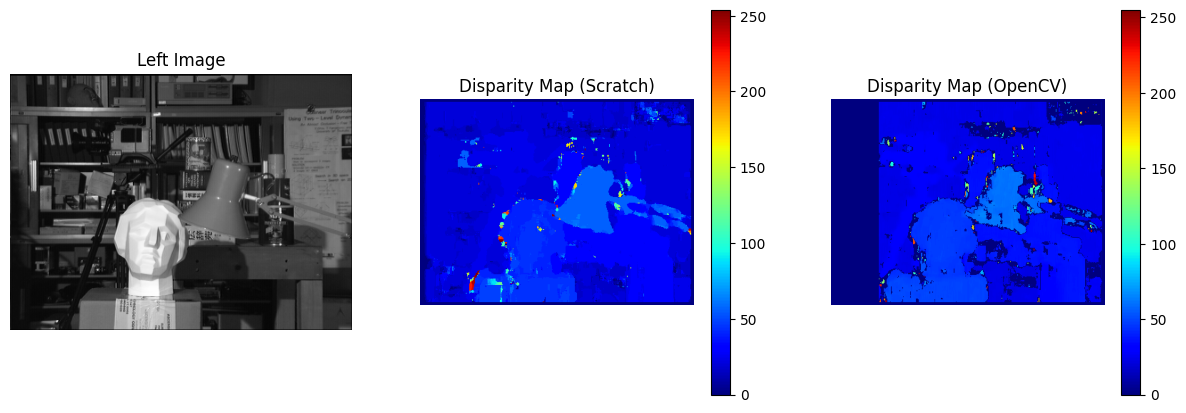

In [4]:
disparity_map_scratch = cv2.normalize(disparity_map_scratch, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
disparity_map_scratch = np.uint8(disparity_map_scratch)


stereo_bm = cv2.StereoBM_create(numDisparities=max_disparity, blockSize=window_size)
disparity_map_opencv = stereo_bm.compute(left_img, right_img)


disparity_map_opencv = cv2.normalize(disparity_map_opencv, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
disparity_map_opencv = np.uint8(disparity_map_opencv)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Left Image")
plt.imshow(left_img, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Disparity Map (Scratch)")
plt.imshow(disparity_map_scratch, cmap='jet')
plt.colorbar()
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Disparity Map (OpenCV)")
plt.imshow(disparity_map_opencv, cmap='jet')
plt.colorbar()
plt.axis("off")

plt.show()